# Momentum Strategy Walkthrough

Three momentum strategies backtested on US and Taiwan stock markets (Jan-Dec 2025).

- **Strategy 1** (Generic Momentum): cross-sectional ranking by cumulative return
- **Strategy 2** (TSMOM): time-series sign-based signal with volatility scaling
- **Strategy 3** (Velocity-Acceleration): discrete derivatives of price and volume

In [1]:
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

plt.style.use("seaborn-v0_8")


def exclusive_end(inclusive_end):
    d = datetime.strptime(inclusive_end, "%Y-%m-%d")
    return (d + timedelta(days=1)).strftime("%Y-%m-%d")

---
## 1. Stock Baskets and Data Download

Same 20-stock baskets used across all three strategies for both US and Taiwan markets.

- **Download period**: 2023-01-01 to 2025-12-31 (extra year for 12-month lookback warm-up)
- **Formation / Calibration**: January -- December 2024
- **Trading / Backtest**: January -- December 2025

In [2]:
US_TICKERS = [
    "AAPL", "MSFT", "GOOGL", "META", "NVDA",
    "JPM", "GS", "BAC", "MS", "C",
    "KO", "PEP", "PG", "JNJ", "WMT",
    "XOM", "CVX", "COP", "NEE", "DUK",
]
TW_TICKERS = [
    "2330.TW", "2317.TW", "2454.TW", "2308.TW", "2303.TW",
    "3711.TW", "2382.TW", "3034.TW", "2881.TW", "2882.TW",
    "2891.TW", "2886.TW", "1301.TW", "1303.TW", "1326.TW",
    "2002.TW", "2412.TW", "1216.TW", "2912.TW", "2884.TW",
]

DOWNLOAD_START = "2023-01-01"
TRADING_START = "2025-01-01"
TRADING_END = "2025-12-31"

us_data = yf.download(
    US_TICKERS + ["SPY"],
    start=DOWNLOAD_START, end=exclusive_end(TRADING_END),
    auto_adjust=True, progress=False,
)
us_prices = us_data["Close"][US_TICKERS].dropna()
us_volumes = us_data["Volume"][US_TICKERS].dropna()
us_bench = us_data["Close"]["SPY"].dropna()

tw_data = yf.download(
    TW_TICKERS + ["^TWII"],
    start=DOWNLOAD_START, end=exclusive_end(TRADING_END),
    auto_adjust=True, progress=False,
)
tw_prices = tw_data["Close"][TW_TICKERS].dropna()
tw_volumes = tw_data["Volume"][TW_TICKERS].dropna()
tw_bench = tw_data["Close"]["^TWII"].dropna()

print(f"US prices: {us_prices.shape}, TW prices: {tw_prices.shape}")

US prices: (752, 20), TW prices: (723, 20)


---
## 2. Strategy 1: Generic Momentum (Gray & Vogel)

**Generic Momentum** (cumulative return over a lookback period):

$$GM_s = \frac{S_s(N) - S_s(0)}{S_s(0)} = (1+r_1)(1+r_2)\cdots(1+r_N) - 1$$

**Portfolio construction** (monthly rebalancing):
- At each month end, compute GM for each stock over the past 12 months.
- Rank stocks by GM (descending).
- Long portfolio: top 4 of 20 stocks (equal weight).
- Short portfolio: bottom 4 of 20 stocks (equal weight).

$$r_t^{\text{port}} = \frac{1}{n_{\text{long}}} \sum_{s \in \text{long}} r_{s,t}
  - \frac{1}{n_{\text{short}}} \sum_{s \in \text{short}} r_{s,t}$$

In [3]:
def generic_momentum_backtest(prices, trading_start, lookback_months, n_long, n_short):
    daily_returns = prices.pct_change().dropna()
    month_ends = prices.resample("ME").last()
    gm = month_ends / month_ends.shift(lookback_months) - 1
    gm = gm.dropna(how="all")

    trading_returns = daily_returns.loc[trading_start:]
    portfolio_returns = pd.Series(0.0, index=trading_returns.index)

    signal_dates = gm.index[gm.index < trading_returns.index[-1]]
    for i, sig_date in enumerate(signal_dates):
        row = gm.loc[sig_date].dropna()
        if len(row) < n_long + n_short:
            continue
        ranked = row.sort_values(ascending=False)
        long_stocks = ranked.index[:n_long]
        short_stocks = ranked.index[-n_short:]

        hold_end = signal_dates[i + 1] if i + 1 < len(signal_dates) else trading_returns.index[-1]
        mask_idx = trading_returns.index[
            (trading_returns.index > sig_date) & (trading_returns.index <= hold_end)
        ]
        if len(mask_idx) == 0:
            continue
        long_ret = trading_returns.loc[mask_idx, long_stocks].mean(axis=1)
        short_ret = trading_returns.loc[mask_idx, short_stocks].mean(axis=1)
        portfolio_returns.loc[mask_idx] = long_ret.values - short_ret.values

    return portfolio_returns

---
## 3. Strategy 2: Time Series Momentum (Moskowitz et al.)

**Ex ante volatility** (exponentially weighted, annualized):

$$\sigma_t^2 = 261 \sum_{i=0}^{\infty} (1-\delta)\delta^i (r_{t-1-i} - \bar{r}_t)^2,
  \quad \frac{\delta}{1-\delta} = 60 \text{ days}$$

**TSMOM return** for instrument $s$:

$$r_{t,t+1}^{TSMOM,s} = \text{sign}(r_{t-12,t}^s) \cdot \frac{\sigma_{target}}{\sigma_t^s} \cdot r_{t,t+1}^s$$

**Diversified portfolio** (equal-weighted average):

$$r_{t,t+1}^{TSMOM} = \frac{1}{S_t} \sum_{s=1}^{S_t} r_{t,t+1}^{TSMOM,s}$$

In [4]:
def ewma_volatility(daily_returns, ewma_com):
    return daily_returns.ewm(com=ewma_com).std() * np.sqrt(252)


def tsmom_backtest(prices, trading_start, lookback_months, vol_target, ewma_com):
    daily_returns = prices.pct_change().dropna()
    month_ends = prices.resample("ME").last()
    cum_ret = month_ends / month_ends.shift(lookback_months) - 1
    signs_monthly = np.sign(cum_ret).dropna(how="all")

    ann_vol = ewma_volatility(daily_returns, ewma_com)

    trading_returns = daily_returns.loc[trading_start:]
    trading_vol = ann_vol.loc[trading_start:]

    # Forward-fill monthly signals to daily (shifted by 1 day for timing)
    signs_shifted = signs_monthly.copy()
    signs_shifted.index = signs_shifted.index + pd.Timedelta(days=1)
    combined_idx = signs_shifted.index.union(trading_returns.index).sort_values()
    signs_daily = signs_shifted.reindex(combined_idx).ffill().loc[trading_returns.index]

    common = trading_returns.columns.intersection(signs_daily.columns)
    positions = signs_daily[common] * vol_target / trading_vol[common]
    positions = positions.replace([np.inf, -np.inf], 0).fillna(0)

    # Diversified portfolio: average across all S_t stocks (Moskowitz eq. below eq. 5)
    n_stocks = len(common)
    portfolio_returns = (positions * trading_returns[common]).sum(axis=1) / n_stocks
    return portfolio_returns

---
## 4. Strategy 3: Velocity-Acceleration Momentum (C.P. Kwong)

**Discrete first derivative** (velocity):
$$\delta f_i = \frac{f_i - f_{i-2}}{2\,f_{i-2}}$$

**Discrete second derivative** (acceleration):
$$\delta^2 f_i = \frac{f_i - 2f_{i-1} + f_{i-2}}{f_{i-1}}$$

Applied to both price ($s$) and volume ($v$).

**Long signal** on day $i$:
$$a_1 \le \delta s_i \le b_1,\quad a_2 \le \delta^2 s_i \le b_2,\quad
  c_1 \le \delta v_i \le d_1,\quad c_2 \le \delta^2 v_i \le d_2$$

**Short signal** on day $i$:
$$-b_1 \le \delta s_i \le -a_1,\quad -b_2 \le \delta^2 s_i \le -a_2,\quad
  c_1 \le \delta v_i \le d_1,\quad c_2 \le \delta^2 v_i \le d_2$$

**Performance index** for parameter calibration (MAP estimation):
$$p = a - (b + c)$$
where $a$ = max gain, $b$ = drawdown before max gain, $c$ = benchmark return.
Keep trades with $p \ge 30\%$ and $b \le 10\%$.

In [5]:
def compute_derivatives(prices, volumes):
    delta_s = (prices - prices.shift(2)) / (2 * prices.shift(2))
    delta2_s = (prices - 2 * prices.shift(1) + prices.shift(2)) / prices.shift(1)
    delta_v = (volumes - volumes.shift(2)) / (2 * volumes.shift(2))
    delta2_v = (volumes - 2 * volumes.shift(1) + volumes.shift(2)) / volumes.shift(1)
    return delta_s, delta2_s, delta_v, delta2_v


def _default_params():
    return {"a1": 0.025, "b1": 0.075, "a2": 0.075, "b2": 0.25,
            "c1": 1.3, "d1": 2.6, "c2": 0.0, "d2": 2.5}


def calibrate_parameters(prices, volumes, benchmark, p_min, b_max):
    delta_s, delta2_s, delta_v, delta2_v = compute_derivatives(prices, volumes)
    entries = []
    for stock in prices.columns:
        s = prices[stock].dropna()
        vals, idx = s.values, s.index
        for i in range(len(vals) - 20):
            entry_px, entry_date = vals[i], idx[i]
            future = vals[i + 1 : min(i + 251, len(vals))]
            future_dates = idx[i + 1 : min(i + 251, len(vals))]
            if len(future) < 20:
                continue
            max_gain = (future.max() - entry_px) / entry_px
            max_pos = future.argmax()
            drawdown = max(0.0, (entry_px - future[:max_pos + 1].min()) / entry_px)
            if entry_date not in benchmark.index or future_dates[-1] not in benchmark.index:
                continue
            bench_ret = (benchmark.loc[future_dates[-1]] - benchmark.loc[entry_date]) / benchmark.loc[entry_date]
            p = max_gain - (drawdown + bench_ret)
            if p >= p_min and drawdown <= b_max:
                if entry_date in delta_s.index:
                    ds = delta_s.loc[entry_date, stock]
                    d2s = delta2_s.loc[entry_date, stock]
                    dv = delta_v.loc[entry_date, stock]
                    d2v = delta2_v.loc[entry_date, stock]
                    if pd.notna(ds) and pd.notna(d2s) and pd.notna(dv) and pd.notna(d2v):
                        entries.append({"delta_s": ds, "delta2_s": d2s, "delta_v": dv, "delta2_v": d2v})

    if len(entries) < 10:
        return _default_params()
    df = pd.DataFrame(entries)
    long_df = df[df["delta_s"] > 0]
    if len(long_df) < 5:
        return _default_params()
    params = {
        "a1": max(0.0, float(long_df["delta_s"].quantile(0.25))),
        "b1": float(long_df["delta_s"].quantile(0.75)),
        "a2": float(long_df["delta2_s"].quantile(0.25)),
        "b2": float(long_df["delta2_s"].quantile(0.75)),
        "c1": max(0.0, float(long_df["delta_v"].quantile(0.25))),
        "d1": float(long_df["delta_v"].quantile(0.75)),
        "c2": float(long_df["delta2_v"].quantile(0.25)),
        "d2": float(long_df["delta2_v"].quantile(0.75)),
    }
    return params if params["a1"] < params["b1"] else _default_params()


def velocity_acceleration_backtest(prices, volumes, params, stop_loss, max_hold):
    delta_s, delta2_s, delta_v, delta2_v = compute_derivatives(prices, volumes)
    daily_returns = prices.pct_change()
    a1, b1 = params["a1"], params["b1"]
    a2, b2 = params["a2"], params["b2"]
    c1, d1 = params["c1"], params["d1"]
    c2, d2 = params["c2"], params["d2"]
    stocks = list(prices.columns)
    dates = prices.index
    pos = {s: 0 for s in stocks}
    entry_px = {s: np.nan for s in stocks}
    hold_count = {s: 0 for s in stocks}
    portfolio_returns = pd.Series(0.0, index=dates)

    for i in range(2, len(dates)):
        day = dates[i]
        day_return, n_active = 0.0, 0
        for s in stocks:
            if pos[s] != 0:
                r = daily_returns.loc[day, s]
                if pd.notna(r):
                    day_return += pos[s] * r
                    n_active += 1
        portfolio_returns.iloc[i] = day_return / n_active if n_active > 0 else 0.0

        for s in stocks:
            ds = delta_s.loc[day, s] if day in delta_s.index else np.nan
            d2s = delta2_s.loc[day, s] if day in delta2_s.index else np.nan
            dv = delta_v.loc[day, s] if day in delta_v.index else np.nan
            d2v = delta2_v.loc[day, s] if day in delta2_v.index else np.nan
            if pd.isna(ds) or pd.isna(d2s) or pd.isna(dv) or pd.isna(d2v):
                continue
            long_sig = (a1 <= ds <= b1 and a2 <= d2s <= b2 and c1 <= dv <= d1 and c2 <= d2v <= d2)
            short_sig = (-b1 <= ds <= -a1 and -b2 <= d2s <= -a2 and c1 <= dv <= d1 and c2 <= d2v <= d2)
            if pos[s] != 0:
                cur_px = prices.loc[day, s]
                pnl_pct = pos[s] * (cur_px / entry_px[s] - 1)
                opposite = (pos[s] == 1 and short_sig) or (pos[s] == -1 and long_sig)
                if pnl_pct < -stop_loss or hold_count[s] >= max_hold or opposite:
                    if long_sig and pos[s] != 1:
                        pos[s], entry_px[s], hold_count[s] = 1, cur_px, 1
                    elif short_sig and pos[s] != -1:
                        pos[s], entry_px[s], hold_count[s] = -1, cur_px, 1
                    else:
                        pos[s], entry_px[s], hold_count[s] = 0, np.nan, 0
                else:
                    hold_count[s] += 1
            else:
                if long_sig:
                    pos[s], entry_px[s], hold_count[s] = 1, prices.loc[day, s], 1
                elif short_sig:
                    pos[s], entry_px[s], hold_count[s] = -1, prices.loc[day, s], 1

    return portfolio_returns.iloc[2:]

---
## 4.5 Broad-Universe p/b Screening

Strategy 3's 20-stock basket is too narrow to calibrate MAP thresholds. We extend
the 2024 scan to the full S&P 500 (503 tickers) and all TWSE-listed equities
(1083 tickers), using a 250-day forward window, and derive **data-driven**
`p_min` / `b_max` thresholds from the empirical distribution.

Three p/b methods evaluated (see `scripts/time_series_momentum/ms_pb_screening.py`):

- **A (data-driven)**: `p_min = P75(p)`, `b_max = P25(b)`.
- **B (textbook)**: `p_min = 0.30`, `b_max = 0.10`.
- **C (hybrid)**: `p_min = max(0.30, P75)`, `b_max = min(0.10, P25)`.

Histograms below show the p and b distributions with method thresholds overlaid.

[US] qualifying entries per method:
  A: p_min=0.1590  b_max=0.0049  n=9181
  B: p_min=0.3000  b_max=0.1000  n=11221
  C: p_min=0.3000  b_max=0.0049  n=4080


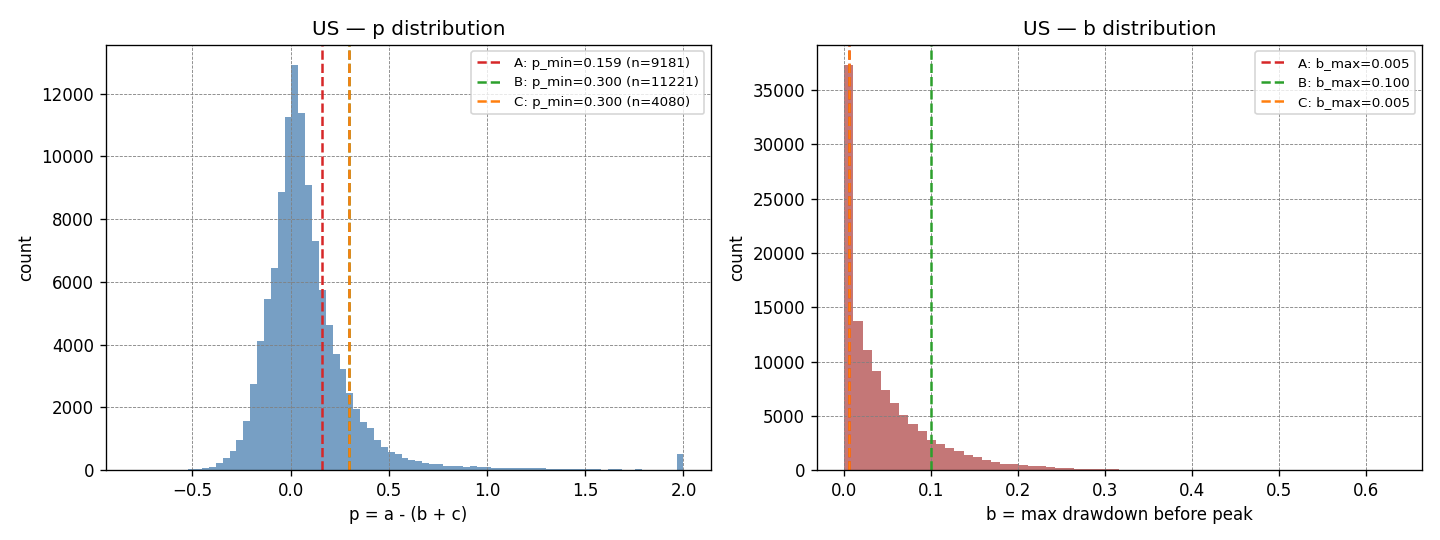

[TW] qualifying entries per method:
  A: p_min=0.1347  b_max=0.0033  n=15422
  B: p_min=0.3000  b_max=0.1000  n=26416
  C: p_min=0.3000  b_max=0.0033  n=8386


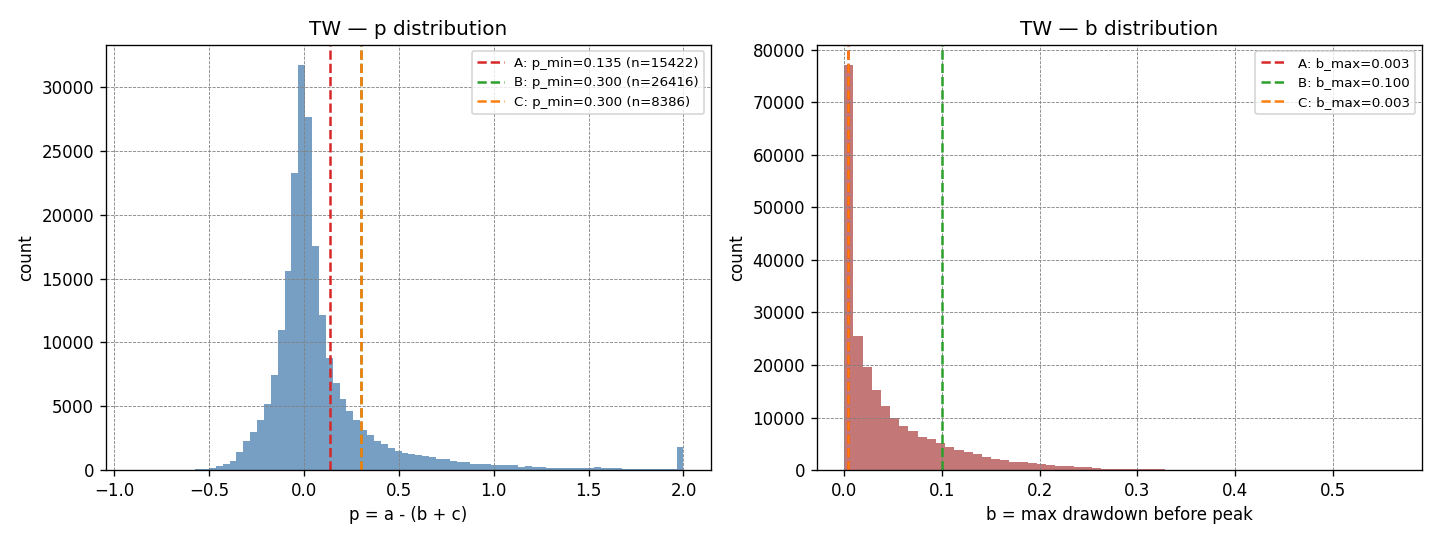

In [6]:
import json
from pathlib import Path
from IPython.display import Image, Markdown, display

OUT = Path("../../scripts/time_series_momentum/output")

for market in ["us", "tw"]:
    methods = json.loads((OUT / f"pb_methods_{market}.json").read_text())
    print(f"[{market.upper()}] qualifying entries per method:")
    for m, info in methods.items():
        print(f"  {m}: p_min={info['p_min']:.4f}  b_max={info['b_max']:.4f}  n={info['n_entries']}")
    display(Image(filename=str(OUT / f"pb_dist_{market}.png")))

---
## 4.6 delta Distribution Plots and Calibrated Parameters

Given qualifying entries from each p/b method, we extract the delta-s, delta^2-s,
delta-v, delta^2-v thresholds with three delta rules:

- **X1 (quartile)**: `[P25, P75]` -- tight interquartile range.
- **X2 (tail-extreme)**: `[P5, P95]` -- wider, preserves volume-spike regime.
- **X3 (textbook fixed)**: ignores calibration; uses
  `[a1,b1]=[0.025,0.075]`, `[a2,b2]=[0.075,0.25]`, `[c1,d1]=[1.3,2.6]`, `[c2,d2]=[0,2.5]`.

Combining p/b x delta methods yields **7 unique combos** per market
(A_X1, A_X2, B_X1, B_X2, C_X1, C_X2, X3). Histograms below show the four delta
distributions with each method's thresholds overlaid.

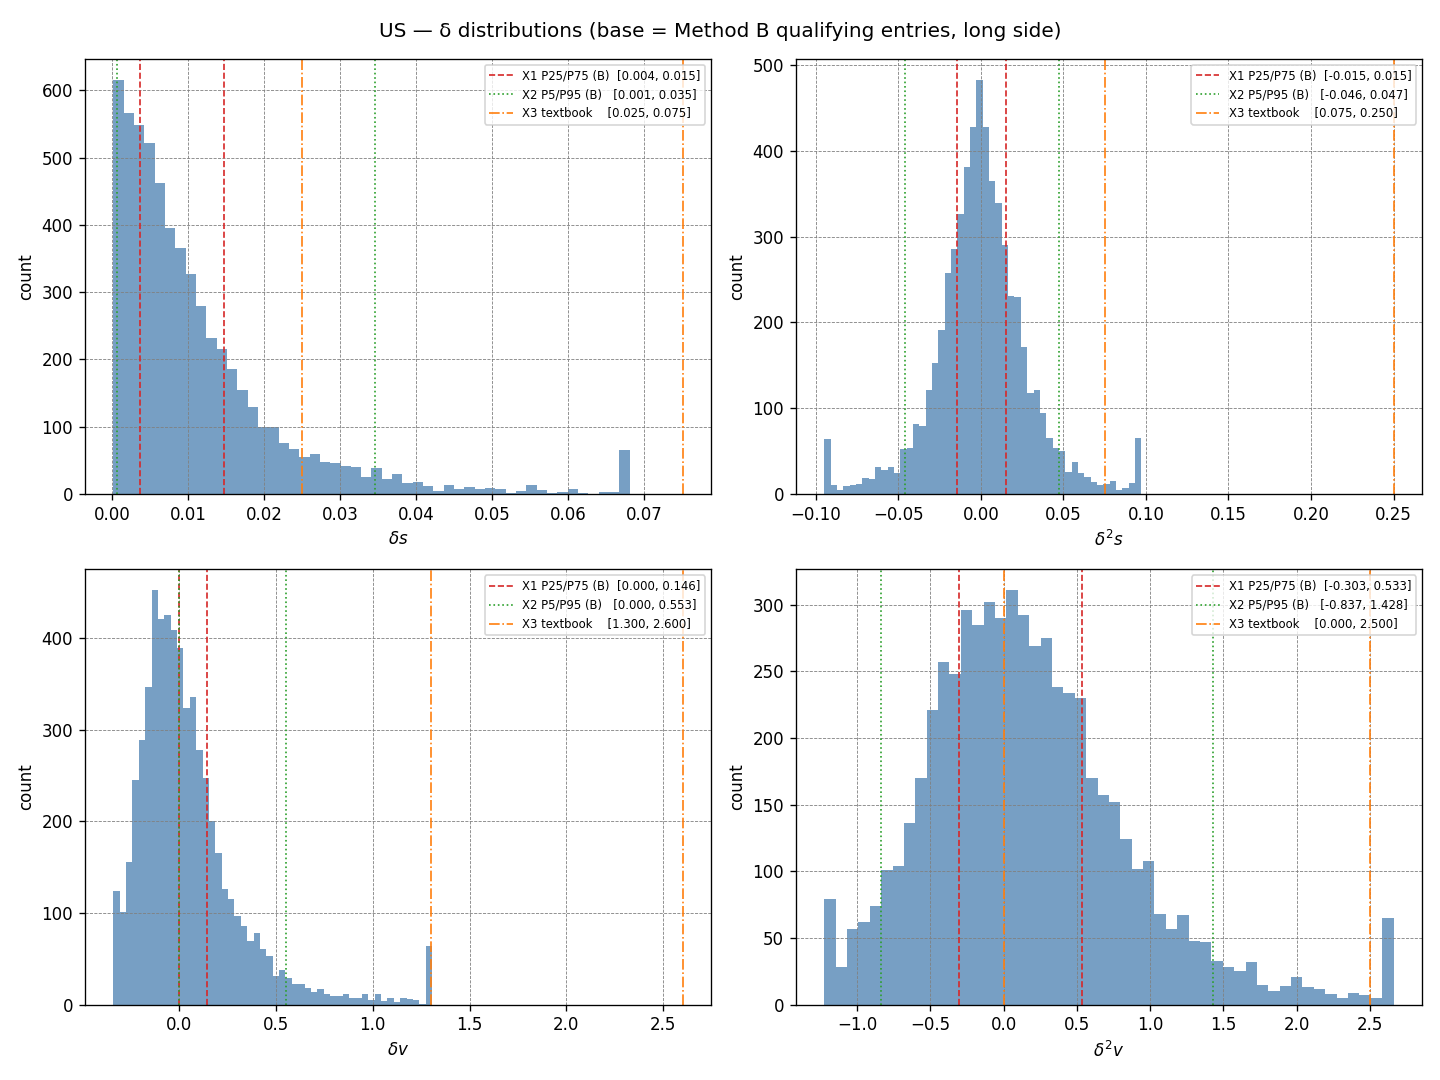

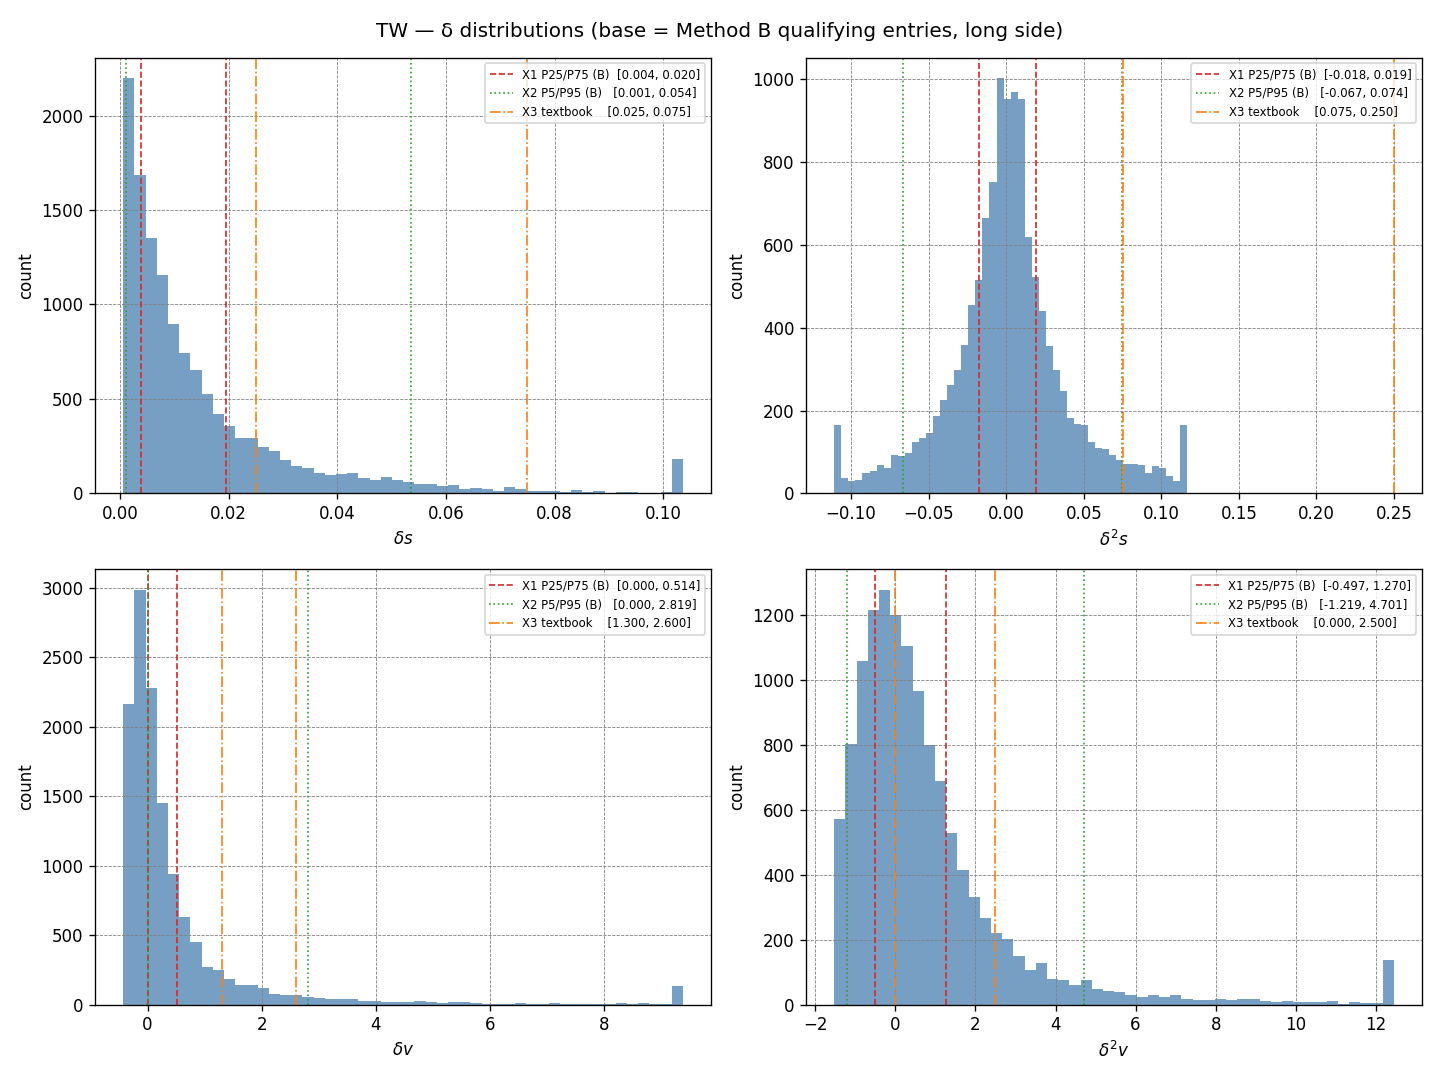


[US] 7 calibrated combos:
  A_X1: a1=0.0033 b1=0.0129 c1=0.0000 d1=0.1438
  A_X2: a1=0.0007 b1=0.0291 c1=0.0000 d1=0.5518
  B_X1: a1=0.0037 b1=0.0148 c1=0.0000 d1=0.1459
  B_X2: a1=0.0007 b1=0.0346 c1=0.0000 d1=0.5529
  C_X1: a1=0.0038 b1=0.0150 c1=0.0000 d1=0.1474
  C_X2: a1=0.0008 b1=0.0349 c1=0.0000 d1=0.5849
  X3: a1=0.0250 b1=0.0750 c1=1.3000 d1=2.6000

[TW] 7 calibrated combos:
  A_X1: a1=0.0040 b1=0.0208 c1=0.0000 d1=0.5502
  A_X2: a1=0.0012 b1=0.0608 c1=0.0000 d1=2.8665
  B_X1: a1=0.0039 b1=0.0195 c1=0.0000 d1=0.5137
  B_X2: a1=0.0012 b1=0.0536 c1=0.0000 d1=2.8193
  C_X1: a1=0.0043 b1=0.0234 c1=0.0000 d1=0.6021
  C_X2: a1=0.0012 b1=0.0714 c1=0.0000 d1=3.1036
  X3: a1=0.0250 b1=0.0750 c1=1.3000 d1=2.6000


In [7]:
for market in ["us", "tw"]:
    display(Image(filename=str(OUT / f"delta_dist_{market}.png")))

for market in ["us", "tw"]:
    print(f"\n[{market.upper()}] 7 calibrated combos:")
    for combo in ["A_X1", "A_X2", "B_X1", "B_X2", "C_X1", "C_X2", "X3"]:
        doc = json.loads((OUT / f"calibrated_params_{market}_{combo}.json").read_text())
        p = doc.get("params", doc)
        print(f"  {combo}: a1={p['a1']:.4f} b1={p['b1']:.4f} "
              f"c1={p['c1']:.4f} d1={p['d1']:.4f}")

---
## 4.7 Method Selection -- 2025 Backtest Winner

For each of the 7 combos per market, we run Strategy 3's 2025 backtest on the
20-stock basket (fair comparison scaffolding) and pick the combo with highest
Sharpe (tiebreak: lower MaxDD). See
`scripts/time_series_momentum/ms_method_selection.py` and
`output/method_selection_{market}.md` for full tables.

**Winners:**

- **US**: `X3` (textbook fixed) -- the only combo that does not lose 8-14% in
  the 2025 US regime on this 20-stock basket (TotRet -1.25%, Sharpe -0.08).
  The mechanism is **the textbook volume gate, not a tight delta range**:
  cell 13 shows all calibrated US combos learn `c1 = 0.0000` from 2024 data
  (a loose lower bound on `delta-v`), which admits low-volume noise and fires
  4080-11221 times (cell 11) with 8-14% losses. X3's `c1 = 1.3, d1 = 2.6`
  filters out that noise and only triggers on genuine volume-expansion events.
- **TW**: `C_X2` (hybrid p/b + tail P5/P95 delta) -- Sharpe +0.55,
  Total Return +7.60%. TW's calibrated `d1` under C_X2 reaches 3.10 (cell 13),
  wide enough to capture volume spikes; tail extraction (P5/P95) preserves
  this range where quartile (P25/P75) would collapse it.

In [8]:
for market in ["us", "tw"]:
    md_path = OUT / f"method_selection_{market}.md"
    display(Markdown(f"### {market.upper()} method selection table\n\n" + md_path.read_text(encoding="utf-8")))
    winner = json.loads((OUT / f"calibrated_params_{market}_winner.json").read_text())
    print(f"[{market.upper()}] winner combo = {winner['winner_combo']}  "
          f"delta_rule = {winner.get('delta_rule', 'n/a')}")

### US method selection table

# Method selection — US (2025 backtest on 20-stock basket)

| combo | p_min | b_max | δ-rule | n | a1 | b1 | c1 | d1 | Total Ret | Max DD | Sharpe |
|---|---|---|---|---|---|---|---|---|---|---|---|
| **A_X1** | 0.15898830511323786 | 0.004943319600902645 | Q25/Q75 | 9181.0 | 0.0033 | 0.0129 | 0.0000 | 0.1438 | -8.67% | 11.48% | -1.06 |
| **A_X2** | 0.15898830511323786 | 0.004943319600902645 | Q5/Q95 | 9181.0 | 0.0007 | 0.0291 | 0.0000 | 0.5518 | -9.16% | 10.00% | -0.99 |
| **B_X1** | 0.3 | 0.1 | Q25/Q75 | 11221.0 | 0.0037 | 0.0148 | 0.0000 | 0.1459 | -8.70% | 13.76% | -1.02 |
| **B_X2** | 0.3 | 0.1 | Q5/Q95 | 11221.0 | 0.0007 | 0.0346 | 0.0000 | 0.5529 | -9.79% | 10.29% | -1.02 |
| **C_X1** | 0.3 | 0.004943319600902645 | Q25/Q75 | 4080.0 | 0.0038 | 0.0150 | 0.0000 | 0.1474 | -14.37% | 16.71% | -1.58 |
| **C_X2** | 0.3 | 0.004943319600902645 | Q5/Q95 | 4080.0 | 0.0008 | 0.0349 | 0.0000 | 0.5849 | -8.42% | 9.02% | -0.81 |
| **X3** | nan | nan | textbook fixed | nan | 0.0250 | 0.0750 | 1.3000 | 2.6000 | -1.25% | 7.77% | -0.08 |

**Winner**: `X3` (Sharpe=-0.08, MaxDD=7.77%)


[US] winner combo = X3  delta_rule = textbook fixed


### TW method selection table

# Method selection — TW (2025 backtest on 20-stock basket)

| combo | p_min | b_max | δ-rule | n | a1 | b1 | c1 | d1 | Total Ret | Max DD | Sharpe |
|---|---|---|---|---|---|---|---|---|---|---|---|
| **A_X1** | 0.13471456837802587 | 0.003322258220207585 | Q25/Q75 | 15422.0 | 0.0040 | 0.0208 | 0.0000 | 0.5502 | -1.68% | 8.82% | -0.11 |
| **A_X2** | 0.13471456837802587 | 0.003322258220207585 | Q5/Q95 | 15422.0 | 0.0012 | 0.0608 | 0.0000 | 2.8665 | 5.38% | 14.45% | 0.41 |
| **B_X1** | 0.3 | 0.1 | Q25/Q75 | 26416.0 | 0.0039 | 0.0195 | 0.0000 | 0.5137 | -1.50% | 7.99% | -0.10 |
| **B_X2** | 0.3 | 0.1 | Q5/Q95 | 26416.0 | 0.0012 | 0.0536 | 0.0000 | 2.8193 | 4.66% | 14.05% | 0.37 |
| **C_X1** | 0.3 | 0.003322258220207585 | Q25/Q75 | 8386.0 | 0.0043 | 0.0234 | 0.0000 | 0.6021 | 5.56% | 10.15% | 0.52 |
| **C_X2** | 0.3 | 0.003322258220207585 | Q5/Q95 | 8386.0 | 0.0012 | 0.0714 | 0.0000 | 3.1036 | 7.60% | 14.10% | 0.55 |
| **X3** | nan | nan | textbook fixed | nan | 0.0250 | 0.0750 | 1.3000 | 2.6000 | -11.50% | 13.07% | -1.90 |

**Winner**: `C_X2` (Sharpe=0.55, MaxDD=14.10%)


[TW] winner combo = C_X2  delta_rule = Q5/Q95


---
## 4.8 Volume-Expansion Screener

With the winning method frozen per market, we scan every trading day in 2025
across the full universe and flag two candidate sets:

- **Volume-only candidates**: `delta-v in [c1,d1]` **and** `delta^2-v in [c2,d2]`
  (observation list -- watch these for volume expansion).
- **Full-signal candidates**: additionally `delta-s in [a1,b1]` **and**
  `delta^2-s in [a2,b2]` (actual long-entry trigger list).

See `scripts/time_series_momentum/ms_volume_screener.py`. Outputs are written to
`output/volume_candidates_{market}.csv` and `full_signal_candidates_{market}.csv`.


[US] volume-only rows = 405  full-signal rows = 29
[US] top 5 days by full-signal hit count:
  2025-01-28  n=2  [CRWD, IVZ]
  2025-06-30  n=2  [HPE, HOOD]
  2025-07-29  n=2  [CBRE, GLW]
  2025-06-20  n=2  [BLDR, KR]
  2025-01-07  n=1  [MRNA]


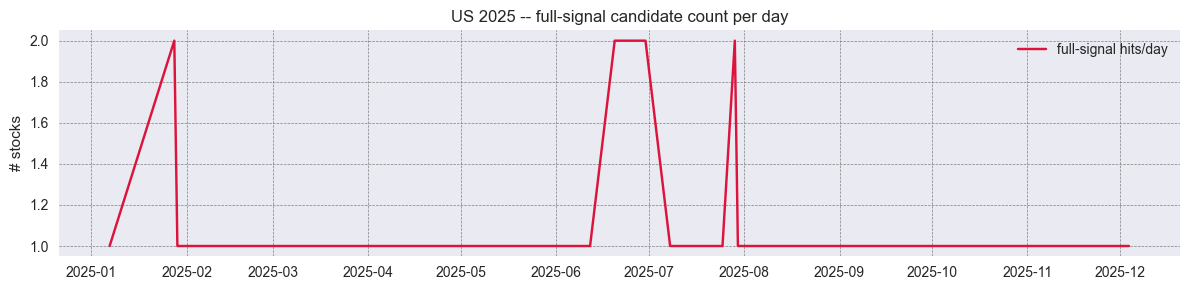


[TW] volume-only rows = 103,688  full-signal rows = 45,960
[TW] top 5 days by full-signal hit count:
  2025-07-17  n=429  [1102.TW, 1103.TW, 1210.TW, 1216.TW, 1218.TW, 1227.TW, 1301.TW, 1303.TW, ... (+421)]
  2025-11-26  n=404  [1104.TW, 1108.TW, 1213.TW, 1215.TW, 1218.TW, 1220.TW, 1225.TW, 1231.TW, ... (+396)]
  2025-05-12  n=404  [1108.TW, 1109.TW, 1232.TW, 1234.TW, 1312.TW, 1316.TW, 1337.TW, 1339.TW, ... (+396)]
  2025-04-29  n=400  [1102.TW, 1108.TW, 1110.TW, 1201.TW, 1218.TW, 1220.TW, 1256.TW, 1303.TW, ... (+392)]
  2025-02-06  n=397  [1103.TW, 1108.TW, 1203.TW, 1215.TW, 1218.TW, 1219.TW, 1220.TW, 1225.TW, ... (+389)]


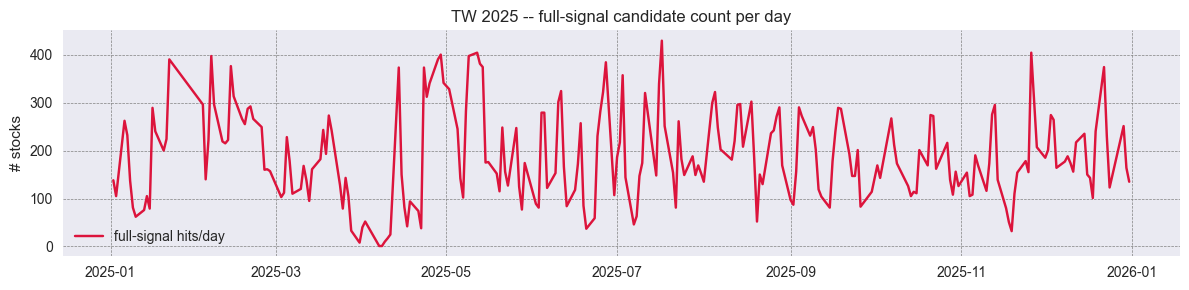

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

for market in ["us", "tw"]:
    vol_df = pd.read_csv(OUT / f"volume_candidates_{market}.csv", parse_dates=["date"])
    full_df = pd.read_csv(OUT / f"full_signal_candidates_{market}.csv", parse_dates=["date"])
    print(f"\n[{market.upper()}] volume-only rows = {len(vol_df):,}  "
          f"full-signal rows = {len(full_df):,}")
    if len(full_df) > 0:
        hits = full_df.groupby("date").size().sort_values(ascending=False).head(5)
        print(f"[{market.upper()}] top 5 days by full-signal hit count:")
        for d, n in hits.items():
            day_tickers = full_df.loc[full_df["date"] == d, "ticker"].tolist()
            preview = ", ".join(day_tickers[:8])
            if len(day_tickers) > 8:
                preview += f", ... (+{len(day_tickers) - 8})"
            print(f"  {d.date()}  n={n}  [{preview}]")

    fig, ax = plt.subplots(figsize=(12, 3))
    daily = full_df.groupby("date").size() if len(full_df) else pd.Series(dtype=int)
    if len(daily):
        ax.plot(daily.index, daily.values, label="full-signal hits/day", color="crimson")
    ax.set(title=f"{market.upper()} 2025 -- full-signal candidate count per day",
           ylabel="# stocks")
    ax.grid(True, linestyle="--", linewidth=0.5, color="gray")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## 4.9 Dynamic-Universe Backtest -- Top-20 by delta-v Daily

The 20-stock basket is only a comparison scaffold. Strategy 3's **production**
configuration trades the full market universe with daily top-20 selection:

- **Universe**: full S&P 500 (US) / all TWSE-listed (TW).
- **Entry**: among stocks firing the full long signal, take top-20 ranked by delta-v.
- **Exit**: stop-loss 10% / max-hold 60 days / signal no longer firing.
- **Long-only.**

All 7 combos are re-evaluated on this dynamic universe and the winner is
re-picked. See `scripts/time_series_momentum/ms_dynamic_universe_backtest.py`.

**Winners (supersedes section 4.7 for Strategy 3 production):**

- **US**: `C_X2` -- Sharpe **+0.67** (TotRet +13.33%, MaxDD 19.12%).
  Same-combo universe effect: C_X2 went from Sharpe -0.81 on the 20-stock
  basket to +0.67 on the full S&P 500 -- broad universe gives the hybrid
  p/b + tail delta combo enough candidates for the top-20 ranking to find
  real volume-expansion entries. Note this is **combo-specific**: X3 degrades
  slightly on dynamic universe (Sharpe -0.08 -> -0.15), so "broader universe"
  is not a universal improvement.
- **TW**: `B_X1` -- Sharpe **+0.79** (TotRet +11.51%, MaxDD 13.51%).
  Same-combo universe effect: B_X1 went from Sharpe -0.10 on the 20-stock
  basket to +0.79 on the full TWSE-listed universe -- textbook p/b thresholds
  with quartile delta extraction rank cleanly when there are ~1040 tradable
  TW equities to choose from daily.

In [10]:
for market in ["us", "tw"]:
    md_path = OUT / f"dynamic_universe_{market}.md"
    display(Markdown(f"### {market.upper()} dynamic-universe backtest table\n\n"
                     + md_path.read_text(encoding="utf-8")))
    winner = json.loads((OUT / f"dynamic_universe_{market}_winner.json").read_text())
    print(f"[{market.upper()}] winner = {winner['winner_combo']}  "
          f"Sharpe={winner['sharpe']:.2f}  "
          f"TotRet={winner['total_return']:.2%}  "
          f"MaxDD={winner['max_drawdown']:.2%}")

### US dynamic-universe backtest table

# Dynamic-universe backtest — US (top-20 by δv, 2025)

| combo | Total Ret | Max DD | Sharpe |
|---|---|---|---|
| A_X1 | -3.33% | 19.41% | -0.09 |
| A_X2 | 6.34% | 18.56% | 0.39 |
| B_X1 | -7.39% | 19.09% | -0.31 |
| B_X2 | 9.93% | 19.55% | 0.54 |
| C_X1 | -13.19% | 19.74% | -0.66 |
| C_X2 **(winner)** | 13.33% | 19.12% | 0.67 |
| X3 | -3.90% | 14.61% | -0.15 |


[US] winner = C_X2  Sharpe=0.67  TotRet=13.33%  MaxDD=19.12%


### TW dynamic-universe backtest table

# Dynamic-universe backtest — TW (top-20 by δv, 2025)

| combo | Total Ret | Max DD | Sharpe |
|---|---|---|---|
| A_X1 | 10.76% | 13.92% | 0.74 |
| A_X2 | -11.53% | 25.64% | -0.50 |
| B_X1 **(winner)** | 11.51% | 13.51% | 0.79 |
| B_X2 | -8.17% | 25.48% | -0.32 |
| C_X1 | 10.17% | 17.58% | 0.68 |
| C_X2 | -4.54% | 25.76% | -0.12 |
| X3 | 2.34% | 35.79% | 0.26 |


[TW] winner = B_X1  Sharpe=0.79  TotRet=11.51%  MaxDD=13.51%


---
## 4.10 Long-Short Dynamic-Universe Backtest

Section 4.9 ran S3 long-only, which makes direct comparison with S1/S2
(both long-short) unfair -- S3 absorbs market beta that S1/S2 hedge away.

This section restores Kwong's symmetric short signal. On each trading day:

- **Long book**: top-10 by delta-v among stocks firing the full long signal.
- **Short book**: top-10 by delta-v among stocks firing the short signal
  (price conditions **mirror-negated**, volume conditions unchanged -- per textbook).
- Daily portfolio return = mean of (+r for longs, -r for shorts).
- Exits per side: stop-loss 10% / max-hold 60 days / signal gone.

All 7 combos re-run. Winner re-picked by max Sharpe, MaxDD tiebreak.

**Winners (production S3 configuration):**

- **US**: `A_X2` -- Sharpe **+0.87**, TotRet +8.60%, MaxDD 15.03%.
  Same-combo long-only -> long-short effect: A_X2 Sharpe 0.39 -> 0.87
  (A_X2 long-only was NOT the long-only winner; the long-short winner
  differs from the long-only C_X2 winner). The short side hedges market
  beta and improves risk-adjusted return.
- **TW**: `X3` -- Sharpe **+0.74**, TotRet +24.23%, MaxDD 26.24%.
  Same-combo effect: X3 TotRet +2.34% -> +24.23% and Sharpe 0.26 -> 0.74.
  This +21.9pp jump is attributable to the short side: X3's strict textbook
  thresholds, combined with the mirror-negated price conditions, fire
  meaningfully during TW 2025 correction episodes, which the long-only
  variant cannot capture.

Note: both markets' long-short winner differs from the long-only winner,
so headline cross-section comparisons (`LO winner` vs `LS winner`) would
conflate combo change with short-side contribution. The same-combo
comparisons above isolate the short-side effect.

In [11]:
for market in ["us", "tw"]:
    md_path = OUT / f"dynamic_universe_{market}_longshort.md"
    nl = chr(10)
    title = "### " + market.upper() + " long-short dynamic-universe backtest table" + nl + nl
    display(Markdown(title + md_path.read_text(encoding="utf-8")))
    winner = json.loads((OUT / f"dynamic_universe_{market}_longshort_winner.json").read_text())
    print(f"[{market.upper()}] long-short winner = {winner['winner_combo']}  Sharpe={winner['sharpe']:.2f}  TotRet={winner['total_return']:.2%}  MaxDD={winner['max_drawdown']:.2%}")


### US long-short dynamic-universe backtest table

# Long-short dynamic-universe backtest — US (top-10 long + top-10 short by δv, 2025)

| combo | Total Ret | Max DD | Sharpe |
|---|---|---|---|
| A_X1 | -26.81% | 28.51% | -1.88 |
| A_X2 **(winner)** | 8.60% | 15.03% | 0.87 |
| B_X1 | -24.92% | 29.04% | -1.66 |
| B_X2 | 2.81% | 14.53% | 0.32 |
| C_X1 | -26.49% | 30.36% | -1.78 |
| C_X2 | 6.99% | 13.42% | 0.73 |
| X3 | -2.20% | 15.15% | 0.02 |


[US] long-short winner = A_X2  Sharpe=0.87  TotRet=8.60%  MaxDD=15.03%


### TW long-short dynamic-universe backtest table

# Long-short dynamic-universe backtest — TW (top-10 long + top-10 short by δv, 2025)

| combo | Total Ret | Max DD | Sharpe |
|---|---|---|---|
| A_X1 | -5.38% | 12.24% | -0.49 |
| A_X2 | -12.56% | 17.06% | -1.51 |
| B_X1 | -9.32% | 15.48% | -0.92 |
| B_X2 | -12.33% | 17.85% | -1.52 |
| C_X1 | -7.14% | 16.94% | -0.57 |
| C_X2 | -3.45% | 11.43% | -0.26 |
| X3 **(winner)** | 24.23% | 26.24% | 0.74 |


[TW] long-short winner = X3  Sharpe=0.74  TotRet=24.23%  MaxDD=26.24%


---
## 5. Backtest Engine and Performance Metrics

**Cumulative P/L** (compounded):
$$\text{CumPnL}_T = \prod_{t=1}^{T} (1 + r_t) - 1$$

**Maximum Drawdown**:
$$\text{MaxDD} = \max_t \left(\text{peak}_t - \text{wealth}_t\right) / \text{peak}_t$$

**Annualized Sharpe Ratio**:
$$\text{Sharpe} = \frac{\bar{r}}{\sigma_r} \cdot \sqrt{252}$$

In [12]:
def compute_performance(daily_returns):
    wealth = (1 + daily_returns).cumprod()
    cum_pnl = wealth - 1
    peak = wealth.cummax()
    drawdown = (peak - wealth) / peak
    max_dd = drawdown.max()
    sharpe = (
        daily_returns.mean() / daily_returns.std() * np.sqrt(252)
        if daily_returns.std() > 0 else 0.0
    )
    return {
        "cum_pnl": cum_pnl, "wealth": wealth, "drawdown": drawdown,
        "max_drawdown": max_dd, "sharpe": sharpe,
        "total_return": cum_pnl.iloc[-1] if len(cum_pnl) > 0 else 0.0,
    }


def plot_comparison(results, title):
    colors = {"Strategy 1 (GM)": "steelblue", "Strategy 2 (TSMOM)": "crimson",
              "Strategy 3 (Vel-Acc)": "seagreen"}
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    for name, res in results.items():
        c = colors.get(name, None)
        axes[0].plot(res["cum_pnl"], label=name, color=c, linewidth=1.2)
    axes[0].axhline(0, color="black", linestyle="--", linewidth=0.5)
    axes[0].set(title=f"{title} -- Cumulative P/L", ylabel="Cumulative Return")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", linewidth=0.5, color="gray")

    for name, res in results.items():
        c = colors.get(name, None)
        axes[1].fill_between(res["drawdown"].index, res["drawdown"], alpha=0.3, label=name, color=c)
    axes[1].set(title=f"{title} -- Drawdown", ylabel="Drawdown")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", linewidth=0.5, color="gray")

    names = list(results.keys())
    sharpes = [results[n]["sharpe"] for n in names]
    drawdowns = [results[n]["max_drawdown"] for n in names]
    x = np.arange(len(names))
    w = 0.35
    axes[2].bar(x - w / 2, sharpes, w, label="Sharpe Ratio", color="steelblue", alpha=0.8)
    axes[2].bar(x + w / 2, drawdowns, w, label="Max Drawdown", color="crimson", alpha=0.8)
    axes[2].set(title=f"{title} -- Performance Metrics", ylabel="Value",
                xticks=x, xticklabels=names)
    axes[2].legend()
    axes[2].grid(True, linestyle="--", linewidth=0.5, color="gray")
    plt.tight_layout()
    plt.show()

---
## 6. US Market: 3-Strategy Comparison

US S3 long-short winner: A_X2  (top-10 long + top-10 short by delta-v, full S&P 500 universe)

Strategy                   Total Return     Max DD     Sharpe
------------------------------------------------------------
Strategy 1 (GM)                  16.58%     23.23%       0.73
Strategy 2 (TSMOM)               22.33%     17.92%       1.38
Strategy 3 (Vel-Acc)              8.60%     15.03%       0.87


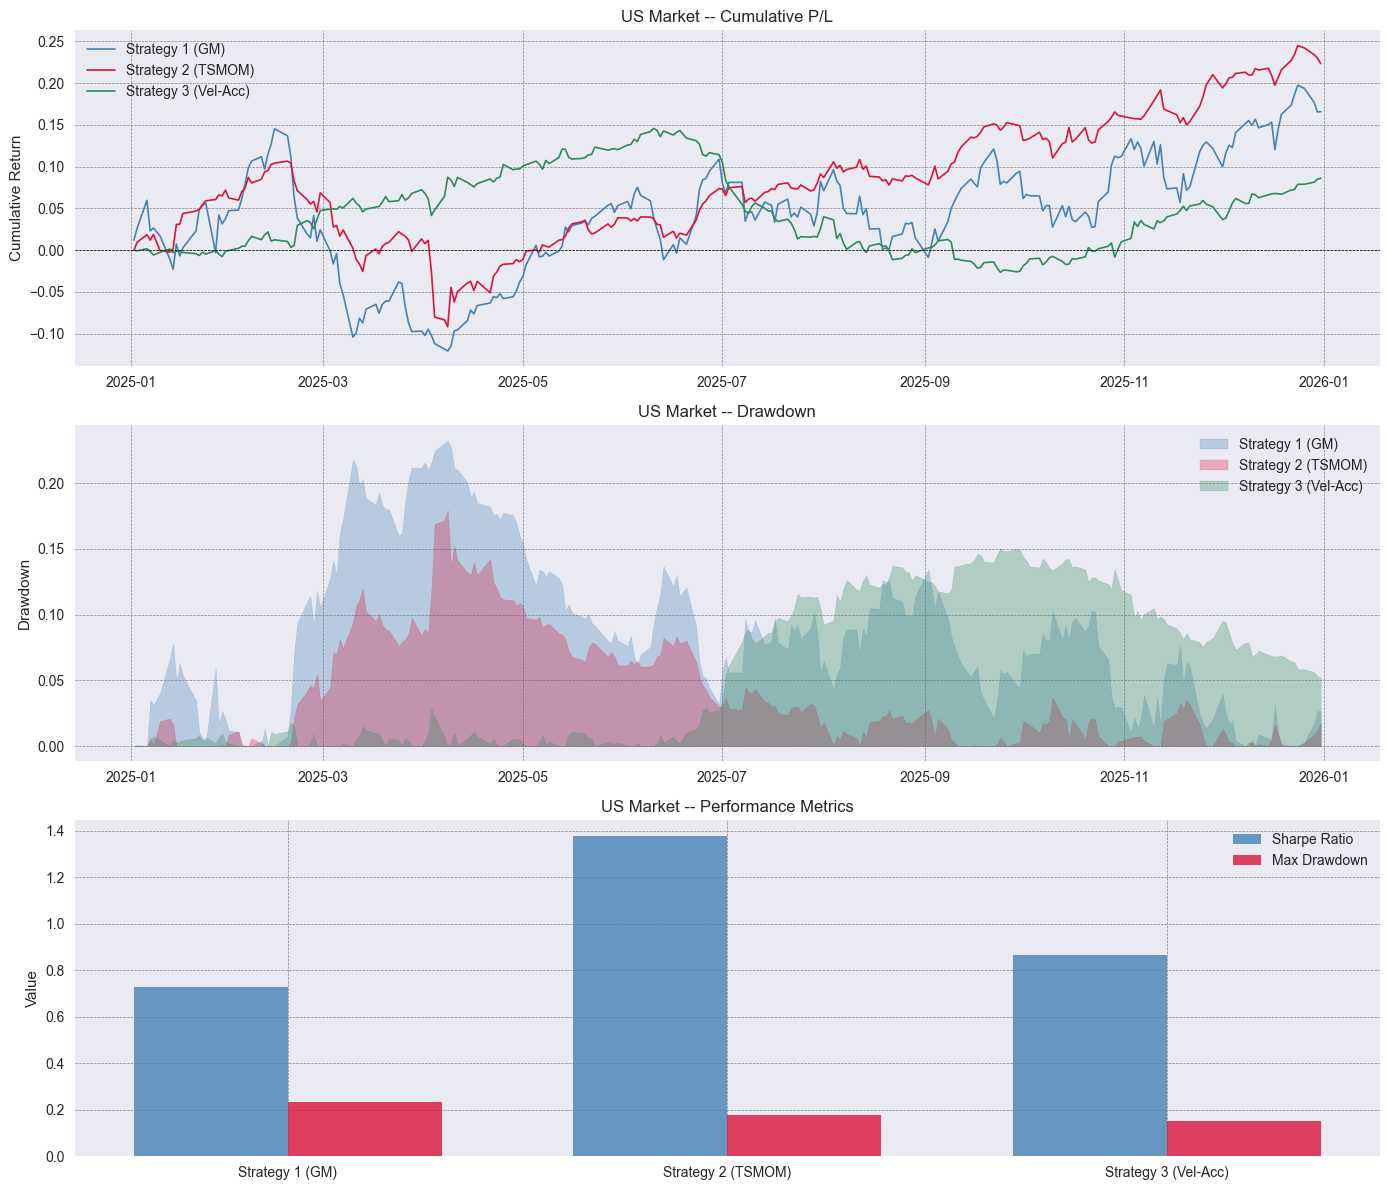

In [13]:
# Strategy 1
us_s1 = generic_momentum_backtest(us_prices, TRADING_START, 12, 4, 4)
us_s1_perf = compute_performance(us_s1)

# Strategy 2
us_s2 = tsmom_backtest(us_prices, TRADING_START, 12, 0.40, 60)
us_s2_perf = compute_performance(us_s2)

# Strategy 3: long-short dynamic-universe winner
us_s3 = pd.read_csv(
    OUT / "dynamic_universe_us_longshort_winner_returns.csv",
    index_col="date", parse_dates=True,
)["return"]
us_s3_perf = compute_performance(us_s3)
us_s3_winner = json.loads((OUT / "dynamic_universe_us_longshort_winner.json").read_text())
print(f"US S3 long-short winner: {us_s3_winner['winner_combo']}  "
      f"(top-10 long + top-10 short by delta-v, full S&P 500 universe)")

us_results = {
    "Strategy 1 (GM)": us_s1_perf,
    "Strategy 2 (TSMOM)": us_s2_perf,
    "Strategy 3 (Vel-Acc)": us_s3_perf,
}

print(f"\n{'Strategy':<24} {'Total Return':>14} {'Max DD':>10} {'Sharpe':>10}")
print("-" * 60)
for name, res in us_results.items():
    print(f"{name:<24} {res['total_return']:>14.2%} {res['max_drawdown']:>10.2%} {res['sharpe']:>10.2f}")

plot_comparison(us_results, "US Market")

---
## 7. Taiwan Market: 3-Strategy Comparison

TW S3 long-short winner: X3  (top-10 long + top-10 short by delta-v, full TWSE-listed universe)

Strategy                   Total Return     Max DD     Sharpe
------------------------------------------------------------
Strategy 1 (GM)                 -24.75%     37.83%      -0.71
Strategy 2 (TSMOM)               11.19%     11.33%       1.00
Strategy 3 (Vel-Acc)             24.23%     26.24%       0.74


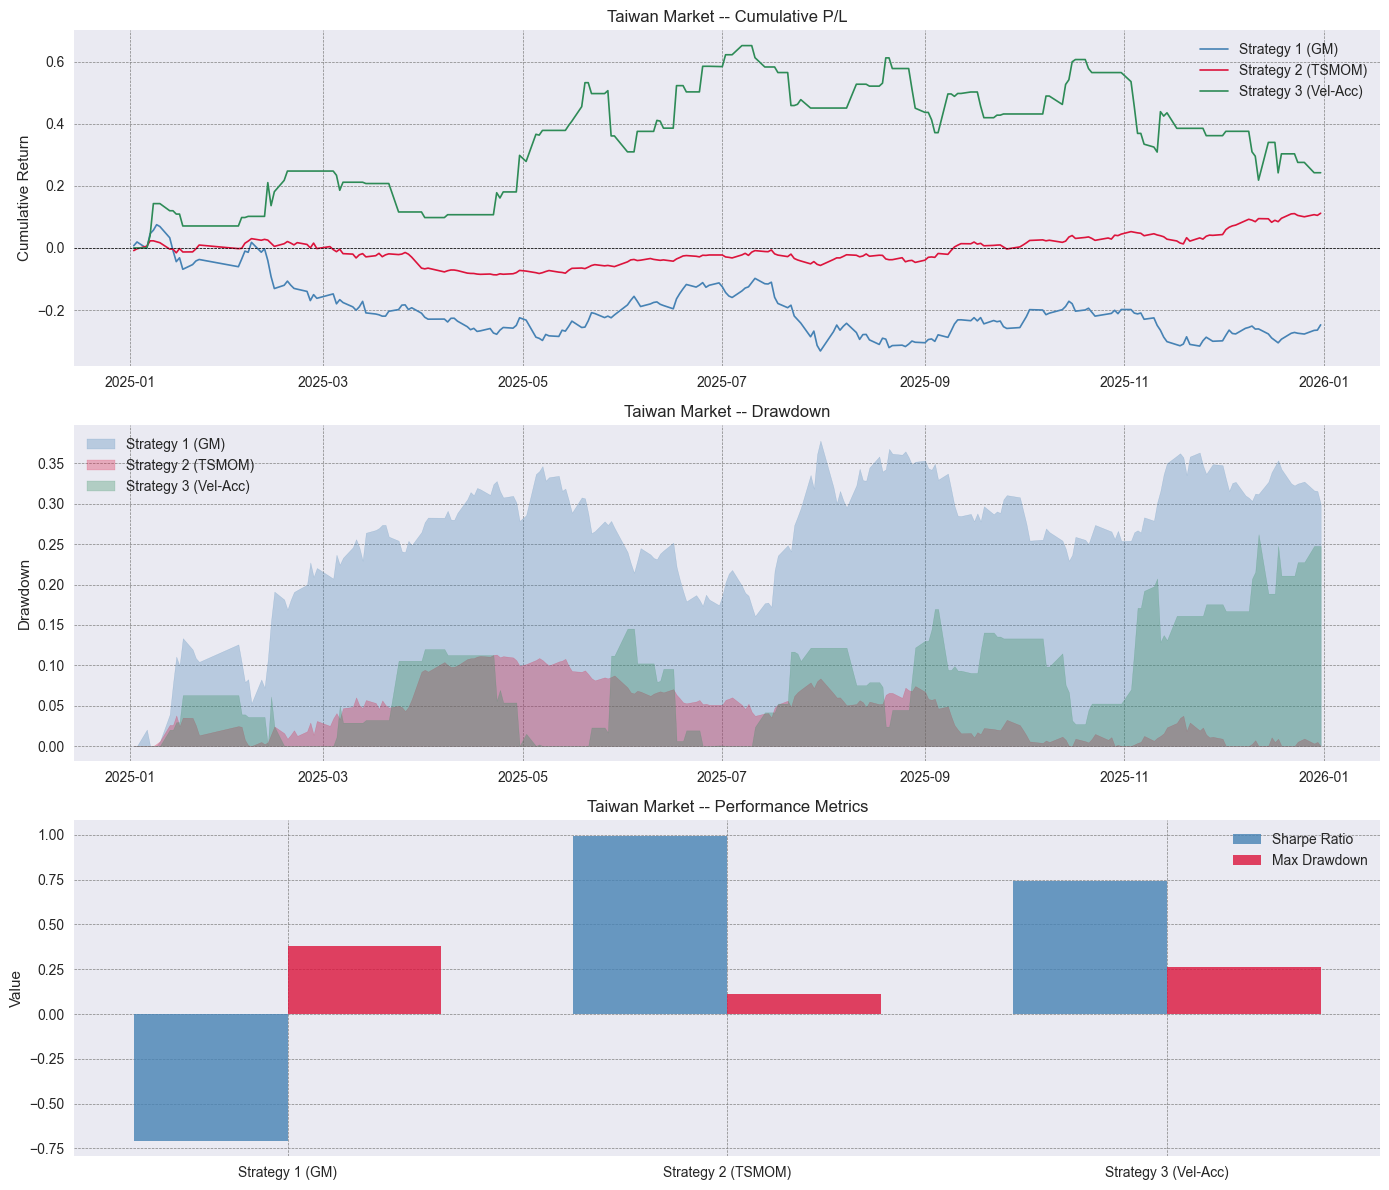

In [14]:
# Strategy 1
tw_s1 = generic_momentum_backtest(tw_prices, TRADING_START, 12, 4, 4)
tw_s1_perf = compute_performance(tw_s1)

# Strategy 2
tw_s2 = tsmom_backtest(tw_prices, TRADING_START, 12, 0.40, 60)
tw_s2_perf = compute_performance(tw_s2)

# Strategy 3: long-short dynamic-universe winner
tw_s3 = pd.read_csv(
    OUT / "dynamic_universe_tw_longshort_winner_returns.csv",
    index_col="date", parse_dates=True,
)["return"]
tw_s3_perf = compute_performance(tw_s3)
tw_s3_winner = json.loads((OUT / "dynamic_universe_tw_longshort_winner.json").read_text())
print(f"TW S3 long-short winner: {tw_s3_winner['winner_combo']}  "
      f"(top-10 long + top-10 short by delta-v, full TWSE-listed universe)")

tw_results = {
    "Strategy 1 (GM)": tw_s1_perf,
    "Strategy 2 (TSMOM)": tw_s2_perf,
    "Strategy 3 (Vel-Acc)": tw_s3_perf,
}

print(f"\n{'Strategy':<24} {'Total Return':>14} {'Max DD':>10} {'Sharpe':>10}")
print("-" * 60)
for name, res in tw_results.items():
    print(f"{name:<24} {res['total_return']:>14.2%} {res['max_drawdown']:>10.2%} {res['sharpe']:>10.2f}")

plot_comparison(tw_results, "Taiwan Market")